In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore") 

In [61]:
df = pd.read_csv("diabetes (1).csv")

In [62]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [63]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [64]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

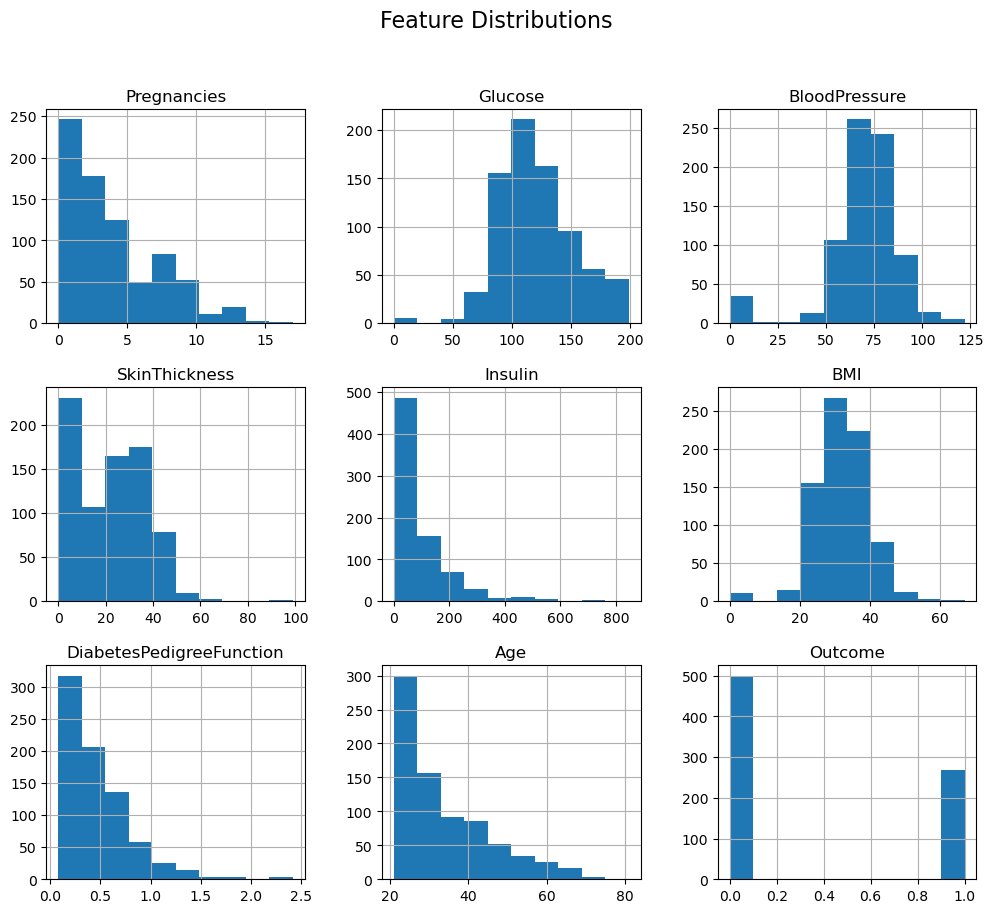

In [65]:
df.hist(figsize=(12, 10))
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

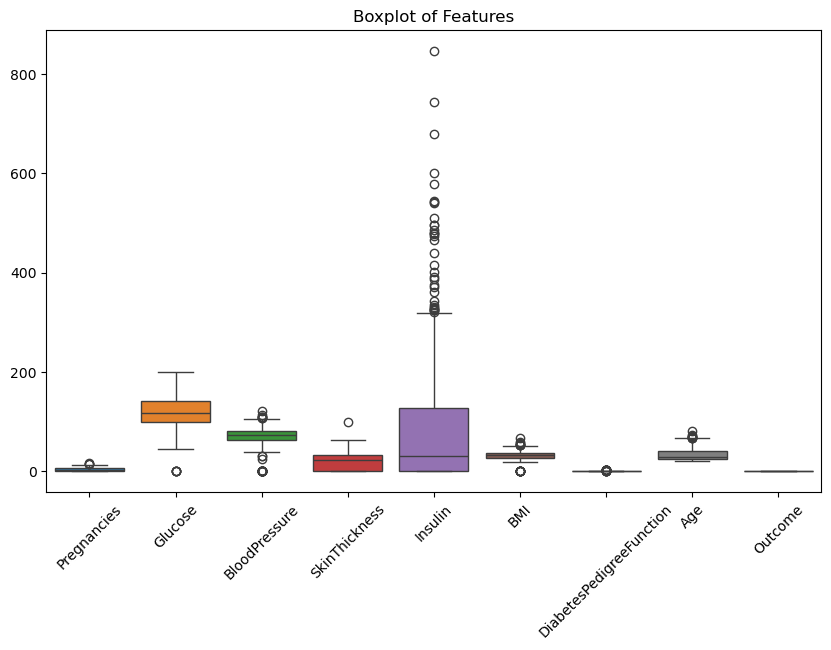

In [66]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title("Boxplot of Features")
plt.xticks(rotation=45)
plt.show()

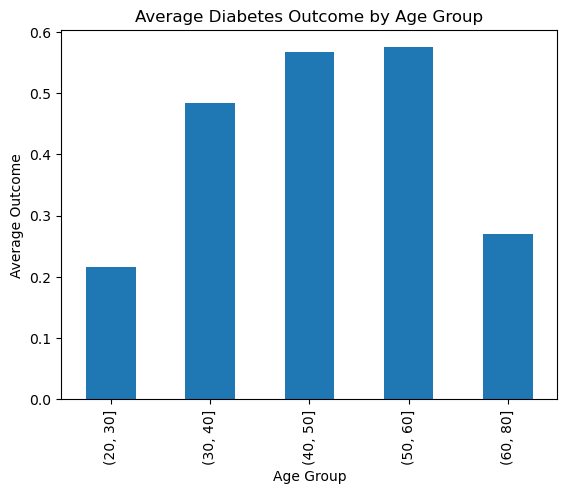

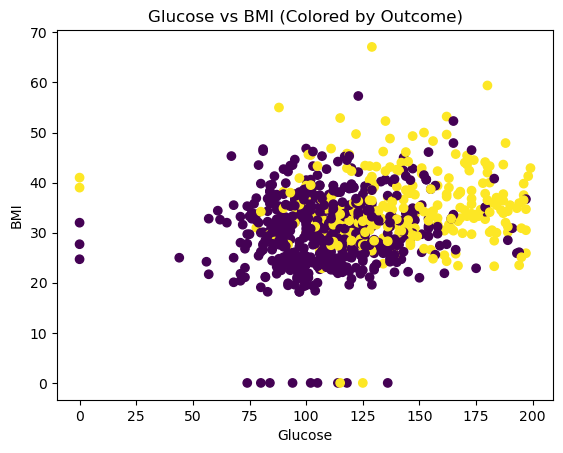

In [67]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[20, 30, 40, 50, 60, 80])

age_outcome = df.groupby("AgeGroup")["Outcome"].mean()

age_outcome.plot(kind="bar")
plt.title("Average Diabetes Outcome by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Outcome")
plt.show()

plt.scatter(df["Glucose"], df["BMI"], c=df["Outcome"])
plt.title("Glucose vs BMI (Colored by Outcome)")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

In [68]:
X = df.drop(columns=["Outcome", "AgeGroup"])
y = df["Outcome"]

In [69]:
pipeline = Pipeline([
("imputer", SimpleImputer(strategy="median")),
("scaler", StandardScaler())
])

X_processed = pipeline.fit_transform(X)

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
X_processed, y,
test_size=0.2,
random_state=42,
stratify=y
)

In [73]:
xgb = XGBClassifier(eval_metric="logloss", random_state=42, verbose=-1)
lgbm = LGBMClassifier(random_state=42, verbose=-1)

In [74]:
xgb_params = {
"n_estimators": [50, 100],
"max_depth": [3, 5],
"learning_rate": [0.05, 0.1]
}

lgbm_params = {
"n_estimators": [50, 100],
"learning_rate": [0.05, 0.1]
}

xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring="accuracy")
lgbm_grid = GridSearchCV(lgbm, lgbm_params, cv=3, scoring="accuracy")

xgb_grid.fit(X_train, y_train)
lgbm_grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=LGBMClassifier(random_state=42, verbose=-1),
             param_grid={'learning_rate': [0.05, 0.1],
                         'n_estimators': [50, 100]},
             scoring='accuracy')

In [75]:
xgb_best = xgb_grid.best_estimator_
lgbm_best = lgbm_grid.best_estimator_

In [76]:
xgb_pred = xgb_best.predict(X_test)
lgbm_pred = lgbm_best.predict(X_test)

In [77]:
def evaluate(y_true, y_pred):
    return [
    accuracy_score(y_true, y_pred),
    precision_score(y_true, y_pred),
    recall_score(y_true, y_pred),
    f1_score(y_true, y_pred)
    ]

results = pd.DataFrame(
[evaluate(y_test, xgb_pred),
evaluate(y_test, lgbm_pred)],
columns=["Accuracy", "Precision", "Recall", "F1-score"],
index=["XGBoost", "LightGBM"]
)

print("\nModel Performance Comparison:")
print(results)


Model Performance Comparison:
          Accuracy  Precision    Recall  F1-score
XGBoost   0.759740   0.673469  0.611111  0.640777
LightGBM  0.772727   0.720930  0.574074  0.639175


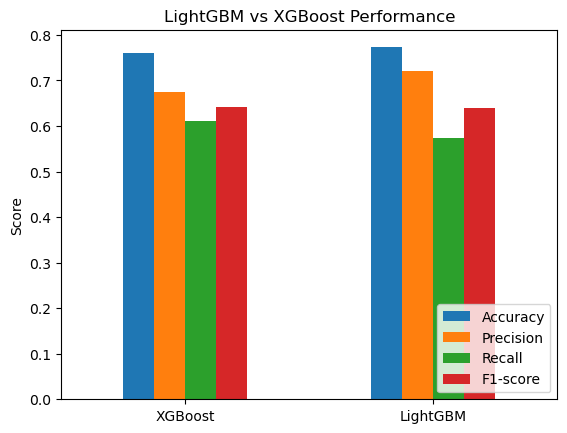

In [78]:
results.plot(kind="bar")
plt.title("LightGBM vs XGBoost Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [79]:
print("""Comparative Analysis Report: LightGBM vs XGBoost

Performance Comparison
The results show that LightGBM achieved slightly higher overall accuracy (77.27%) compared to XGBoost (75.97%). LightGBM also demonstrated higher precision, meaning it produced fewer false positive predictions.
However, XGBoost achieved higher recall, indicating it was better at identifying actual positive cases. This is particularly important in medical applications where missing a true case may have serious consequences.
Both models produced nearly identical F1-scores, suggesting a similar balance between precision and recall.

Strengths and Weaknesses

XGBoost
Strengths:
* Higher recall (better detection of positive cases)
* Strong balance between precision and recall

Weaknesses:
* Slightly lower accuracy and precision

LightGBM
Strengths:
* Higher overall accuracy
* Better precision (fewer false alarms)
* Efficient and fast training
Weaknesses:
* Slightly lower recall

Practical Implications
If the goal is to minimize missed medical diagnoses, XGBoost may be preferred due to its higher recall. If reducing false alarms and improving overall accuracy is more important, LightGBM is a better choice.
Conclusion:

Both LightGBM and XGBoost are effective classification algorithms. The final model selection should depend on whether recall or precision is more critical for the specific application.
""")

Comparative Analysis Report: LightGBM vs XGBoost

Performance Comparison
The results show that LightGBM achieved slightly higher overall accuracy (77.27%) compared to XGBoost (75.97%). LightGBM also demonstrated higher precision, meaning it produced fewer false positive predictions.
However, XGBoost achieved higher recall, indicating it was better at identifying actual positive cases. This is particularly important in medical applications where missing a true case may have serious consequences.
Both models produced nearly identical F1-scores, suggesting a similar balance between precision and recall.

Strengths and Weaknesses

XGBoost
Strengths:
* Higher recall (better detection of positive cases)
* Strong balance between precision and recall

Weaknesses:
* Slightly lower accuracy and precision

LightGBM
Strengths:
* Higher overall accuracy
* Better precision (fewer false alarms)
* Efficient and fast training
Weaknesses:
* Slightly lower recall

Practical Implications
If the goal is to